In [1]:
from waveformutils.datasource import DataSource
from waveformutils.plotting.swarmmpl import swarmw, swarmwg

DataSource: EW Client pubavo1.wr.usgs.gov:16022
>>> seismology.datasource[__init__].get_waveforms_from_client()
- Loading AV.BOGO.--.BHZ
1 Trace(s) in Stream:
AV.BOGO..BHZ | 2021-11-02T12:00:00.000000Z - 2021-11-03T15:59:53.180000Z | 50.0 Hz, 5039660 samples (masked)


<AxesSubplot:title={'center':'Waveform'}, ylabel='AV.BOGO..BHZ'>

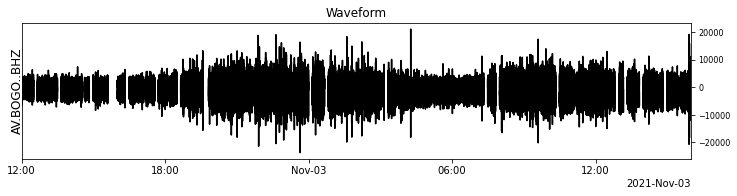

In [2]:
ds = DataSource('ew', 'pubavo1.wr.usgs.gov:16022')
#nslc_list = ['AV.BOGO.--.BHZ', 'AV.OKFG.--.BHZ', 'AV.MCIR.--.BHZ'] # Bogoslof
nslc_list = ['AV.BOGO.--.BHZ'] # Bogoslof
#st = ds.getWaveforms(nslc_list, '2021/11/01', '2021/11/03', verbose=False) # time period w gappy data
st = ds.getWaveforms(nslc_list, '2021/11/02 12:00:00', '2021/11/03 16:00:00', verbose=False) # shorter time period w gappy data
st_original = st.copy()
print(st_original)
swarmw(st_original)


## Try w np.nan

1 Trace(s) in Stream:
AV.BOGO..BHZ | 2021-11-02T12:00:00.000000Z - 2021-11-03T15:59:53.180000Z | 50.0 Hz, 5039660 samples
         network: AV
         station: BOGO
        location: 
         channel: BHZ
       starttime: 2021-11-02T12:00:00.000000Z
         endtime: 2021-11-03T15:59:53.180000Z
   sampling_rate: 50.0
           delta: 0.02
            npts: 5039660
           calib: 1.0
      processing: ['ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 2, 13, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', 'ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 3, 16, 0)::fill_value=None::nearest_sample=False::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', "ObsPy 1.2.2: filter(options={'freqmin': 1, 'freqmax': 5}::type='bandpass')", "ObsPy 1.2.2: taper(max_length=None::max_percentage=0.01::side='both'::type='hann')"]


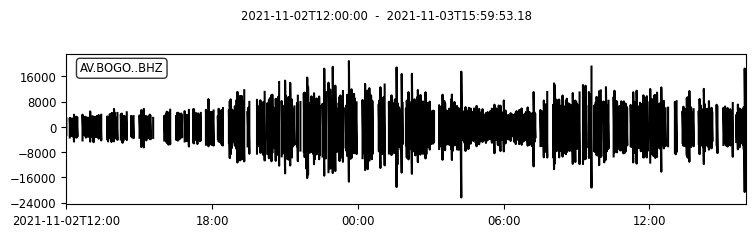

/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


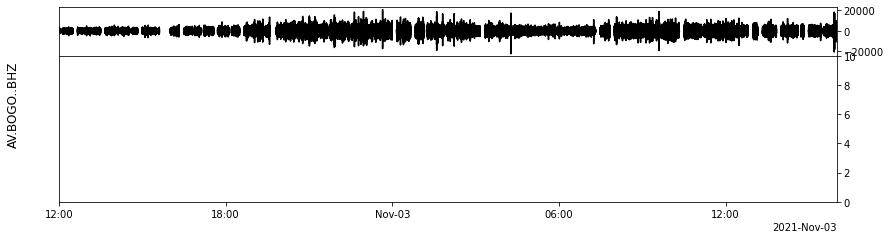

In [3]:
import numpy as np
tr = st[0]
st2 = tr.split().filter('bandpass', freqmin=1, freqmax=5).taper(max_percentage=0.01).merge(fill_value=np.nan)
print(st2)
print(st2[0].stats)
st2.plot()
fig = swarmwg(st2)

1 Trace(s) in Stream:
AV.BOGO..BHZ | 2021-11-02T12:00:00.000000Z - 2021-11-03T15:59:53.180000Z | 50.0 Hz, 5039660 samples
         network: AV
         station: BOGO
        location: 
         channel: BHZ
       starttime: 2021-11-02T12:00:00.000000Z
         endtime: 2021-11-03T15:59:53.180000Z
   sampling_rate: 50.0
           delta: 0.02
            npts: 5039660
           calib: 1.0
      processing: ['ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 2, 13, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', 'ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 3, 16, 0)::fill_value=None::nearest_sample=False::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', "ObsPy 1.2.2: filter(options={'freqmin': 1, 'freqmax': 5}::type='bandpass')", "ObsPy 1.2.2: taper(max_length=None::max_percentage=0.01::side='both'::type='hann')"]


/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/anaconda3/envs/seismology38/lib/python3.8/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


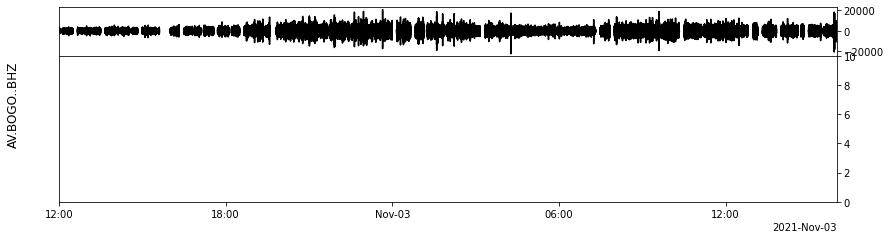

In [5]:
from waveformutils.streamutils import replaceGapValue
st3 = replaceGapValue(st2, gap_value=np.nan, fill_value=0) # This isn't working
print(st3)
print(st3[0].stats)
fig = swarmwg(st3)

## Try w 0

         network: AV
         station: BOGO
        location: 
         channel: BHZ
       starttime: 2021-11-02T12:00:00.000000Z
         endtime: 2021-11-03T15:59:53.180000Z
   sampling_rate: 50.0
           delta: 0.02
            npts: 5039660
           calib: 1.0
      processing: ['ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 2, 13, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', 'ObsPy 1.2.2: trim(endtime=UTCDateTime(2021, 11, 3, 16, 0)::fill_value=None::nearest_sample=False::pad=False::starttime=UTCDateTime(2021, 11, 2, 12, 0))', 'ObsPy 1.2.2: split()', 'ObsPy 1.2.2: split()', "ObsPy 1.2.2: filter(options={'freqmin': 1, 'freqmax': 5}::type='bandpass')", "ObsPy 1.2.2: taper(max_length=None::max_percentage=0.01::side='both'::type='hann')"]


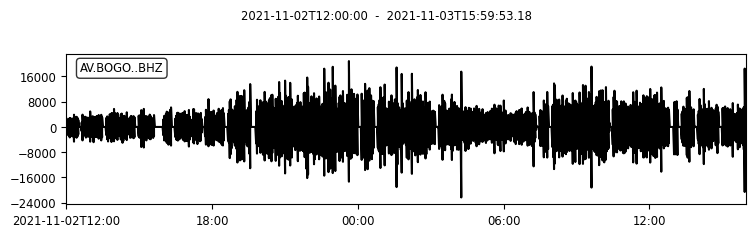

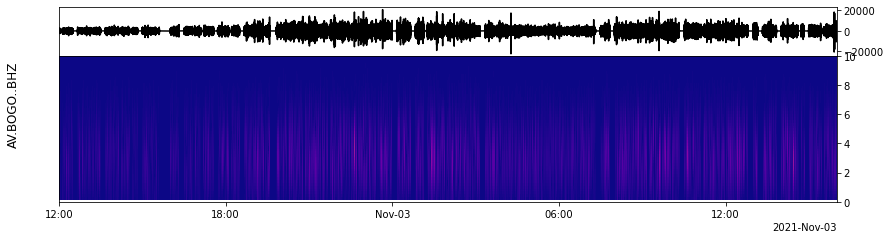

In [8]:
import numpy as np
from waveformutils.plotting.swarmmpl import swarmwg
tr = st[0]
st2 = tr.split().filter('bandpass', freqmin=1, freqmax=5).taper(max_percentage=0.01).merge(fill_value=0)
print(st2[0].stats)
st2.plot()
fig = swarmwg(st2)

## Clean w for loop, Use 0